Import Libraries

In [13]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [14]:
dataset = load_dataset("imdb")
df = pd.DataFrame(dataset["train"])
texts = df["text"].head(2000)
print(texts.head(10))

0    I rented I AM CURIOUS-YELLOW from my video sto...
1    "I Am Curious: Yellow" is a risible and preten...
2    If only to avoid making this type of film in t...
3    This film was probably inspired by Godard's Ma...
4    Oh, brother...after hearing about this ridicul...
5    I would put this at the top of my list of film...
6    Whoever wrote the screenplay for this movie ob...
7    When I first saw a glimpse of this movie, I qu...
8    Who are these "They"- the actors? the filmmake...
9    This is said to be a personal film for Peter B...
Name: text, dtype: object


In [16]:
# Text Cleaning
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)     # remove HTML
    text = re.sub(r"[^a-zA-Z]", " ", text) # replace with space (IMPORTANT)
    text = re.sub(r"\s+", " ", text)       # remove extra spaces
    return text.strip()

df["cleaned"] = df["text"].apply(clean_text)

In [17]:
#Tokenization
import nltk
nltk.download("punkt")
# nltk.download("punkt_tab")
df["tokens"] = df["cleaned"].apply(nltk.word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [18]:
# Stopword Removal
from nltk.corpus import stopwords
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
df["filtered"] = df["tokens"].apply(lambda x: [word for word in x if word not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
# Lemmatization
import spacy
nlp = spacy.load("en_core_web_sm")

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]

df["lemmatized"] = df["filtered"].apply(lemmatize)

TF IDF

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df["lemmatized"].apply(lambda x: " ".join(str(item) for item in x)))

Word 2 Vec

In [21]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df["lemmatized"],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print(w2v_model.wv.most_similar("movie"))

[('film', 0.7152275443077087), ('honestly', 0.6966972947120667), ('sure', 0.6609320640563965), ('flick', 0.660033106803894), ('personally', 0.6570793390274048), ('amazed', 0.6534692645072937), ('usually', 0.6428438425064087), ('probably', 0.6423472762107849), ('anyways', 0.6353631615638733), ('admit', 0.635250449180603)]


Sentence Embeddings

In [23]:
def sentence_vector(tokens):
  vecs = [w2v_model .wv[w] for w in tokens if w in w2v_model.wv]
  return np.mean(vecs, axis=0) if vecs else np.zeros(100)

df["vector"] = df["lemmatized"].apply(sentence_vector)

In [26]:
import numpy as np

matrix = np.stack(df["vector"].values)
print(matrix.shape)

(25000, 100)


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(matrix)

# view small portion
print(sim_matrix[:5, :5])

[[1.         0.9173572  0.87359864 0.8520735  0.94553196]
 [0.9173572  1.0000001  0.7855995  0.88711274 0.8994254 ]
 [0.87359864 0.7855995  1.0000001  0.834867   0.8701611 ]
 [0.8520735  0.88711274 0.834867   0.9999999  0.84472066]
 [0.94553196 0.8994254  0.8701611  0.84472066 0.99999994]]


Similarity Search

In [28]:
def find_similar(query, top_n=5):
    query = clean_text(query)
    query_tokens = query.split()

    query_vec = sentence_vector(query_tokens).reshape(1, -1)

    similarities = cosine_similarity(query_vec, matrix)[0]

    top_indices = similarities.argsort()[-top_n:][::-1]

    return df.iloc[top_indices][["text"]]

In [29]:
find_similar("this movie is very interesting and good")

,text
8034,"Creepshow 2 had a lot of potential, they just ..."
22583,The Night Listener is probably not one of Will...
14380,this movie was rather awful Vipul Shah's last ...
24093,This movie is a half-documentary...and it is p...
10058,I had never thought the standard of Yashraj fi...


Visualizations

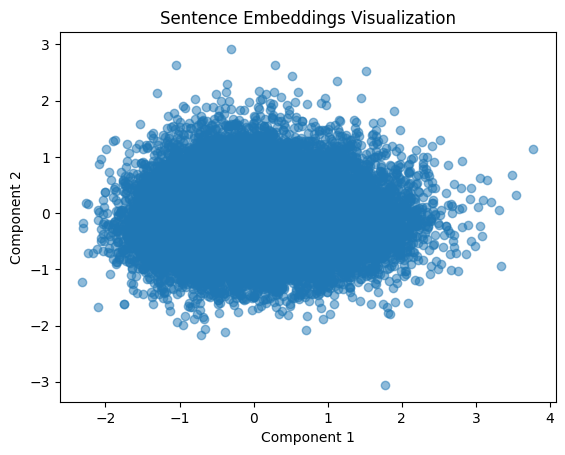

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reduce dimensions
pca = PCA(n_components=2)
reduced = pca.fit_transform(matrix)

# plot
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5)
plt.title("Sentence Embeddings Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

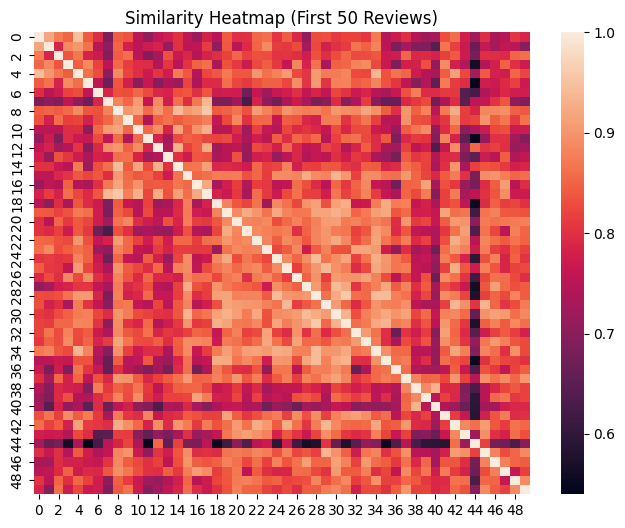

In [31]:
import seaborn as sns

sim_subset = cosine_similarity(matrix[:50], matrix[:50])

plt.figure(figsize=(8,6))
sns.heatmap(sim_subset)

plt.title("Similarity Heatmap (First 50 Reviews)")
plt.show()

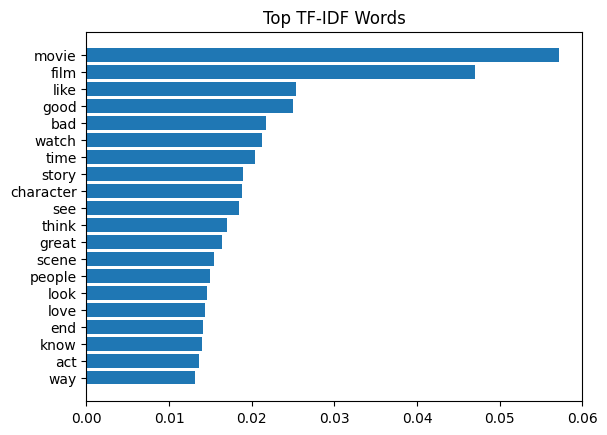

In [38]:
feature_names = vectorizer.get_feature_names_out()
scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

top_idx = scores.argsort()[-20:]

plt.figure()
plt.barh([feature_names[i] for i in top_idx], scores[top_idx])
plt.title("Top TF-IDF Words")
plt.show()

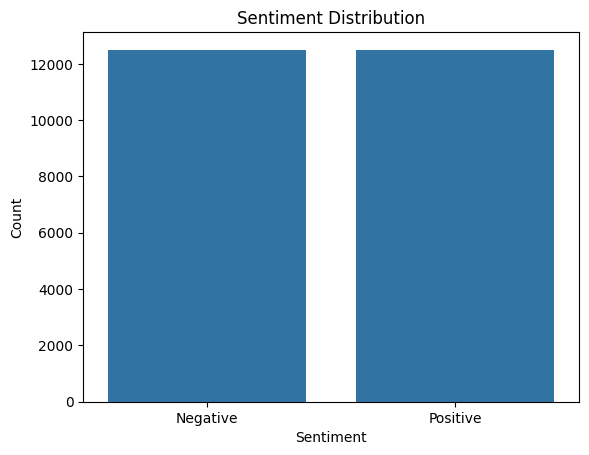

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# count labels
sentiment_counts = df["label"].value_counts()

# plot
plt.figure()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)

plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()